### Detecção de Anomalias em Transações
#### Cleiton Santos

In [1]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Problemas de classificação desbalanceada
Fraudes são raras -> modelo pode ignorar a classe 1.

In [2]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

### Featuring Engineering
Criamos variáveis que ajudam o modelo.

In [3]:
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [5]:
from sklearn.model_selection import train_test_split

x = df.drop(["Class", "Time"], axis=1)
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42 
)

### Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [7]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.62      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



Accuracy pode ser alta mesmo sem detectar fraudes.
Por isso usamos:
  * Recall(mais importante)
  * Precision
  * F1-score

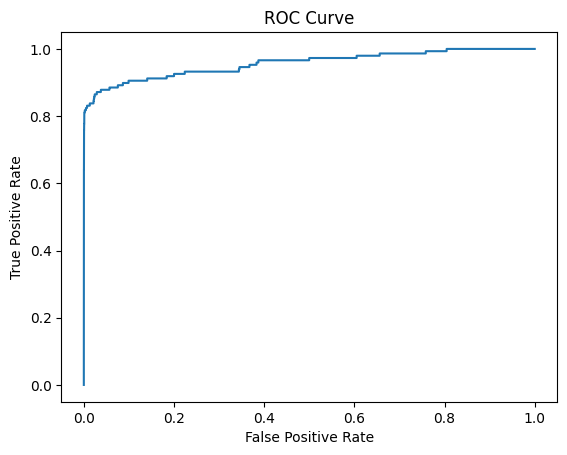

AUC: 0.9565964229074612


In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

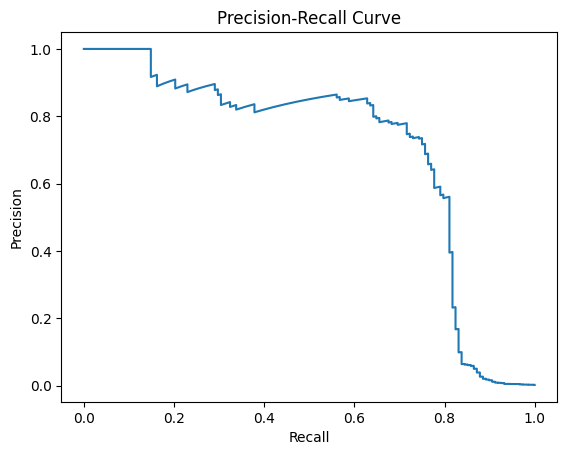

In [9]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

### Balanceamento de dados

In [10]:
# Undersampling
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [11]:
# Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE()

x_res, y_res = smote.fit_resample(x_train, y_train)

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.81      0.77      0.79       148

    accuracy                           1.00     85443
   macro avg       0.90      0.88      0.89     85443
weighted avg       1.00      1.00      1.00     85443



In [13]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

In [14]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.78      0.66      0.72       148

    accuracy                           1.00     85443
   macro avg       0.89      0.83      0.86     85443
weighted avg       1.00      1.00      1.00     85443



### Modelo Avançado - XGBoost
XGBoost é um dos algoritmos mais usados em competições e mercado.
Ele é mais poderoso que Random Forest para muitos problemas. 

In [ ]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
)

# Agora sim: treinando o modelo nos dados gerados pelo SMOTE!
xgb.fit(x_res, y_res)

y_pred_xgb = xgb.predict(x_test)

/home/cleiton/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:48:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [16]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.82      0.82      0.82       148

    accuracy                           1.00     85443
   macro avg       0.91      0.91      0.91     85443
weighted avg       1.00      1.00      1.00     85443



### Importância das variáveis.
Ajuda entender quais variáveis influenciam mais modelos. 

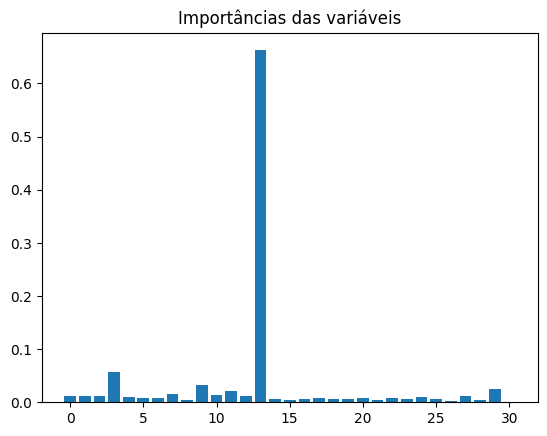

In [17]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importâncias das variáveis")
plt.show()

### Ajuste de hiperparâmetros
Testamos várias combinações para melhorar o modelo.

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(x_train, y_train)

print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'max_depth': 5, 'n_estimators': 100}


### Explicabilidade(SHAP)
SHAP mostra como cada variável influencia a decisão do modelo.

In [ ]:
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


PermutationExplainer explainer: 101it [00:20,  2.46it/s]                         


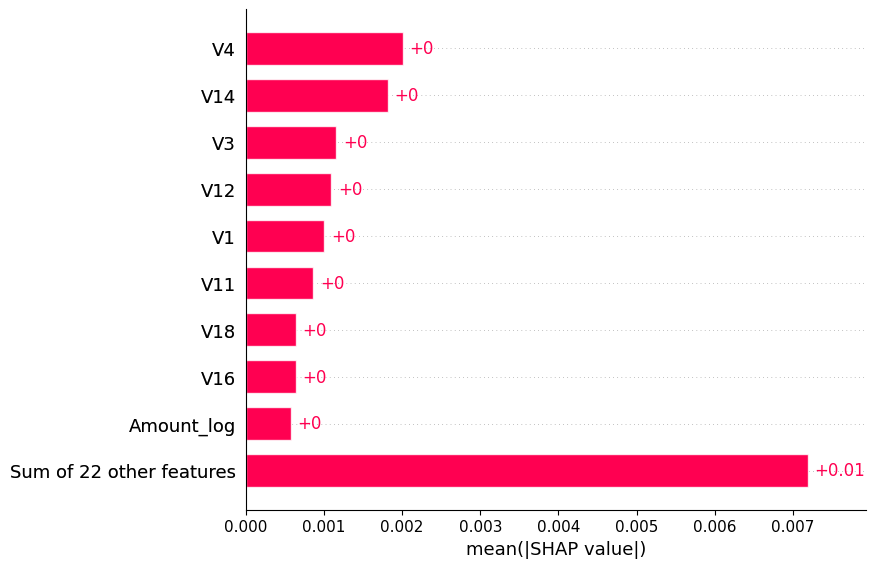

In [31]:
import shap

explainer = shap.Explainer(xgb.predict, x_test)
shap_values = explainer(x_test[:100])
shap.plots.bar(shap_values)
